Завантажуємо бібліотеки

In [5]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

Підготуємо дані та виведемо деякі для демонстрації

In [2]:
path = kagglehub.dataset_download("zaheenhamidani/ultimate-spotify-tracks-db")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\savedheart\.cache\kagglehub\datasets\zaheenhamidani\ultimate-spotify-tracks-db\versions\3


In [6]:
data_df = pd.read_csv('C:/Users/savedheart/.cache/kagglehub/datasets/zaheenhamidani/ultimate-spotify-tracks-db/versions/3/SpotifyFeatures.csv')
print(f"Розмір датасету: {data_df.shape}")

print("\nПерший 5 рядків:")
print(data_df.head())

print("\nНазви колонок:")
print(data_df.columns)

print("\nСтатистика по числових ознаках:")
print(data_df.describe())

Розмір датасету: (232725, 18)

Перший 5 рядків:
   genre        artist_name                        track_name  \
0  Movie     Henri Salvador       C'est beau de faire un Show   
1  Movie  Martin & les fées  Perdu d'avance (par Gad Elmaleh)   
2  Movie    Joseph Williams    Don't Let Me Be Lonely Tonight   
3  Movie     Henri Salvador    Dis-moi Monsieur Gordon Cooper   
4  Movie       Fabien Nataf                         Ouverture   

                 track_id  popularity  acousticness  danceability  \
0  0BRjO6ga9RKCKjfDqeFgWV           0         0.611         0.389   
1  0BjC1NfoEOOusryehmNudP           1         0.246         0.590   
2  0CoSDzoNIKCRs124s9uTVy           3         0.952         0.663   
3  0Gc6TVm52BwZD07Ki6tIvf           0         0.703         0.240   
4  0IuslXpMROHdEPvSl1fTQK           4         0.950         0.331   

   duration_ms  energy  instrumentalness key  liveness  loudness   mode  \
0        99373   0.910             0.000  C#    0.3460    -1.828  Major

Обираємо числові ознаки для кластеризації

In [27]:
features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'duration_ms',
]

x = data_df[features].copy()

print(f"Розмір таблиці з ознаками: {x.shape}")
print("\nПропуски по колонках:")
print(x.isnull().sum())

x = x.dropna()
print(f"Розмір таблиці після видалення пропусків: {x.shape}")

Розмір таблиці з ознаками: (232725, 10)

Пропуски по колонках:
danceability        0
energy              0
loudness            0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
dtype: int64
Розмір таблиці після видалення пропусків: (232725, 10)


Стандартизуємо числові ознаки

In [28]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

print("Після стандартизації маємо масив розміру:")
print(x_scaled.shape)

Після стандартизації маємо масив розміру:
(232725, 10)


Залишаємо популярні треки для візуалізації

In [29]:
popular_df = data_df[data_df['popularity'] >= 85].copy()
popular_df = popular_df.dropna(subset = features)

print(f"Розмір таблиці після фільтрації popularity >= 85: {popular_df.shape}")

Розмір таблиці після фільтрації popularity >= 85: (417, 18)


Обираємо оптимальне k - Метод ліктя

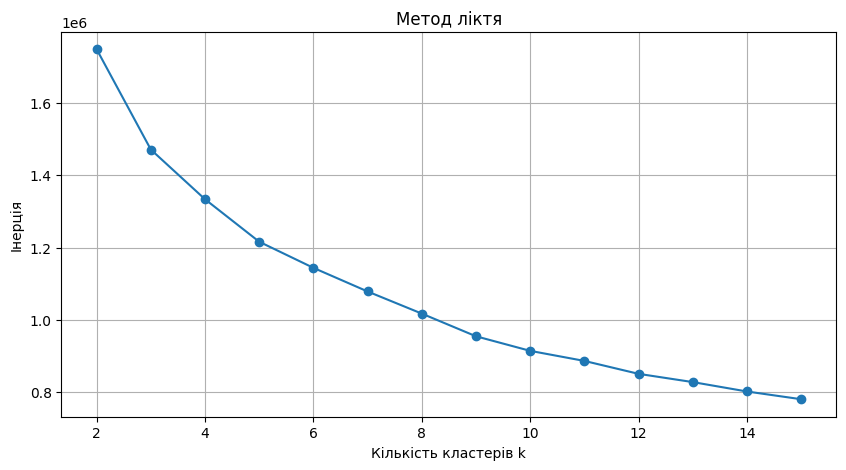

In [30]:
inertia_values = []
k_values = range(2, 16)

for k in k_values:
    model = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    model.fit(x_scaled)
    inertia_values.append(model.inertia_)

plt.figure(figsize = (10, 5))
plt.plot(k_values, inertia_values, marker = 'o')
plt.title("Метод ліктя")
plt.xlabel('Кількість кластерів k')
plt.ylabel('Інерція')
plt.grid(True)
plt.show()

In [31]:
k_opt = 4

kmeans = KMeans(n_clusters = k_opt, random_state = 42, n_init = 10)
clusters = kmeans.fit_predict(x_scaled)

x_with_clusters = x.copy()
x_with_clusters['cluster'] = clusters

print("Кількість треків у кожному кластері:")
print(x_with_clusters['cluster'].value_counts().sort_index())

Кількість треків у кожному кластері:
cluster
0    135733
1     30264
2     56517
3     10211
Name: count, dtype: int64


Додаємо кластери до основного DataFrame та виводимо деякі для демонстрації

In [32]:
data_df_no_na = data_df.dropna(subset = features).copy()
data_df_no_na['cluster'] = clusters

print(data_df_no_na[['track_name', 'artist_name', 'cluster']].head())

                         track_name        artist_name  cluster
0       C'est beau de faire un Show     Henri Salvador        0
1  Perdu d'avance (par Gad Elmaleh)  Martin & les fées        0
2    Don't Let Me Be Lonely Tonight    Joseph Williams        2
3    Dis-moi Monsieur Gordon Cooper     Henri Salvador        2
4                         Ouverture       Fabien Nataf        2


Застосуємо PCA для зменшення розмірності до 2 компонент для 2D-візуалізації

In [33]:
pca_2 = PCA(n_components = 2)
x_pca_2 = pca_2.fit_transform(x_scaled)

pca_df_2 = pd.DataFrame(x_pca_2, columns = ['PC1', 'PC2'])
pca_df_2['cluster'] = clusters

print(f"Після PCA маємо розмірність: {pca_df_2.shape}")
print("\nПояснена дисперсія:")
print(pca_2.explained_variance_ratio_)
print(f"Сумарна пояснена дисперсія: {sum((pca_2.explained_variance_ratio_ * 100)):.2f}%")

Після PCA маємо розмірність: (232725, 3)

Пояснена дисперсія:
[0.34589712 0.16220454]
Сумарна пояснена дисперсія: 50.81%


Візуалізуємо в 2D

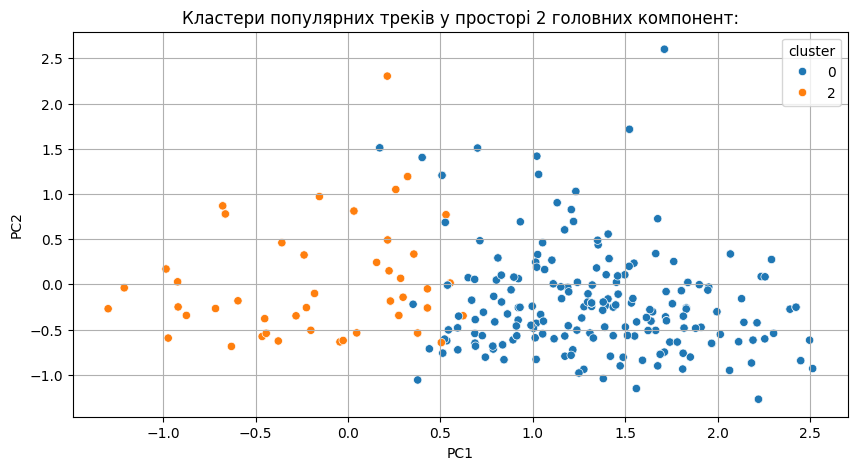

In [34]:
popular_scaled = scaler.transform(popular_df[features])
popular_pca_2 = pca_2.transform(popular_scaled)
popular_clusters = kmeans.predict(popular_scaled)

popular_vis_2 = pd.DataFrame(popular_pca_2, columns = ['PC1', 'PC2'])
popular_vis_2['cluster'] = popular_clusters
popular_vis_2['track_name'] = popular_df['track_name'].values
popular_vis_2['artist_name'] = popular_df['artist_name'].values
popular_vis_2['popularity'] = popular_df['popularity'].values

plt.figure(figsize = (10, 5))
sns.scatterplot(data = popular_vis_2, x = 'PC1', y = 'PC2', hue = "cluster", palette = "tab10")
plt.title("Кластери популярних треків у просторі 2 головних компонент:")
plt.grid(True)
plt.show()

fig = px.scatter(popular_vis_2, x = "PC1", y = "PC2", color = popular_vis_2['cluster'].astype(str), hover_data = ['track_name', 'artist_name', 'popularity'], title = "Інтерактивна 2D-візуалізація кластерів популярних треків")
fig.show()

Застосуємо PCA для зменшення розмірності до 3 компонент для 3D-візуалізації

In [35]:
pca_3 = PCA(n_components = 3)
x_pca_3 = pca_3.fit_transform(x_scaled)

pca_df_3 = pd.DataFrame(x_pca_3, columns = ['PC1', 'PC2', 'PC3'])
pca_df_3['cluster'] = clusters

print(f"Після PCA маємо розмірність: {pca_df_3.shape}")
print("\nПояснена дисперсія:")
print(pca_3.explained_variance_ratio_)
print(f"Сумарна пояснена дисперсія: {sum((pca_3.explained_variance_ratio_ * 100)):.2f}%")

Після PCA маємо розмірність: (232725, 4)

Пояснена дисперсія:
[0.34589712 0.16220454 0.11671687]
Сумарна пояснена дисперсія: 62.48%


Візуалізуємо в 3D

In [36]:
popular_pca_3 = pca_3.transform(popular_scaled)

popular_vis_3 = pd.DataFrame(popular_pca_3, columns=['PC1', 'PC2', 'PC3'])
popular_vis_3['cluster'] = popular_clusters
popular_vis_3['track_name'] = popular_df['track_name'].values
popular_vis_3['artist_name'] = popular_df['artist_name'].values
popular_vis_3['popularity'] = popular_df['popularity'].values

fig = px.scatter_3d(popular_vis_3, x="PC1", y="PC2", z = "PC3", color=popular_vis_3['cluster'].astype(str),
                 hover_data=['track_name', 'artist_name', 'popularity'],
                 title="Інтерактивна 3D-візуалізація кластерів популярних треків")
fig.show()

Середні значення ознак в кластерах

In [37]:
cluster_means = data_df_no_na.groupby('cluster')[features].mean()

print("Середні значення ознак для кожного кластера:")
print(cluster_means)

Середні значення ознак для кожного кластера:
         danceability    energy   loudness  speechiness  acousticness  \
cluster                                                                 
0            0.615961  0.735163  -6.257914     0.100905      0.125471   
1            0.288391  0.163888 -20.724869     0.046527      0.850458   
2            0.547486  0.377727 -11.119864     0.072159      0.618929   
3            0.561953  0.664221 -11.954493     0.873818      0.785865   

         instrumentalness  liveness   valence       tempo    duration_ms  
cluster                                                                   
0                0.068319  0.207730  0.554687  124.420413  232022.081248  
1                0.674867  0.154250  0.149064  102.416333  263282.379395  
2                0.084968  0.172005  0.386423  113.115605  225886.413433  
3                0.001371  0.729879  0.414307   98.278085  243991.078543  


Heatmap середніх значень ознак

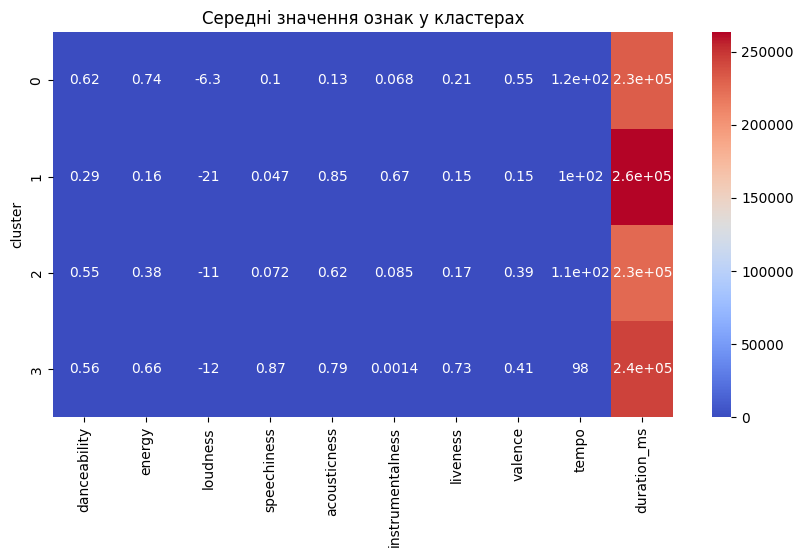

In [38]:
plt.figure(figsize = (10, 5))
sns.heatmap(cluster_means, annot = True, cmap = 'coolwarm')
plt.title("Середні значення ознак у кластерах")
plt.show()

Кількість треків у кожному кластері

Кількість треків у кожному кластері:
cluster
0    135733
1     30264
2     56517
3     10211
Name: count, dtype: int64


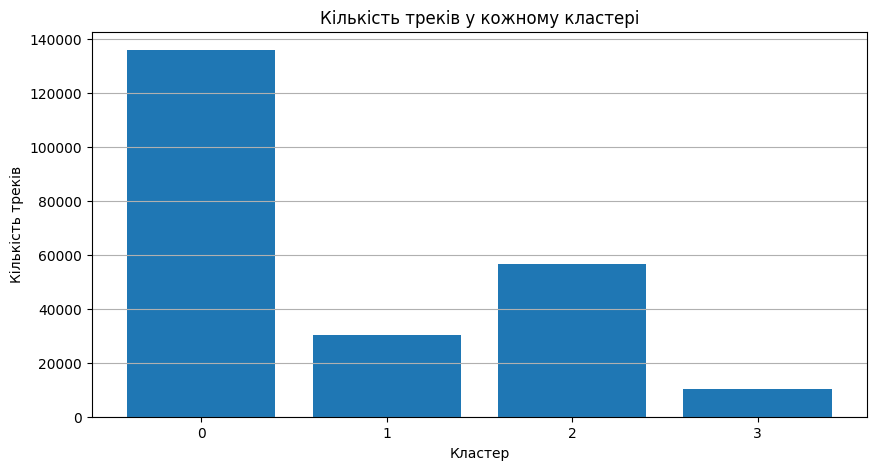

In [39]:
cluster_counts = data_df_no_na['cluster'].value_counts().sort_index()

print("Кількість треків у кожному кластері:")
print(cluster_counts)

plt.figure(figsize = (10, 5))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)
plt.title("Кількість треків у кожному кластері")
plt.xlabel("Кластер")
plt.ylabel("Кількість треків")
plt.grid(axis = "y")
plt.show()

Приклади треків із кожного кластера

In [40]:
for cl in sorted(data_df_no_na['cluster'].unique()):
    print(f"\nКластер {cl}:")
    print(data_df_no_na[data_df_no_na['cluster'] == cl][['track_name', 'artist_name', 'popularity']].head(5))


Кластер 0:
                          track_name           artist_name  popularity
0        C'est beau de faire un Show        Henri Salvador           0
1   Perdu d'avance (par Gad Elmaleh)     Martin & les fées           1
8                              Helka                Chorus           0
9          Les bisous des bisounours   Le Club des Juniors          10
12            J'ai demandé à la lune  Idoles De La Musique           4

Кластер 1:
                                           track_name         artist_name  \
10  Symphony No.4 In E Minor Op.98 : IV. Allegro E...   Leopold Stokowski   
11  The Hanging (Maverick - Original Motion Pictur...        Randy Newman   
14                                       Keys of Love  Richard M. Sherman   
38                                          Afterglow  Richard M. Sherman   
41         Bourrée, From English Suite No. 2, BWV 807   Leopold Stokowski   

    popularity  
10           0  
11           2  
14           0  
38           0  
41

Приклад інтерпретації:
Кластер 0 - треки з вищою енергією, танцювальністю та темпом.
Кластер 1 - спокійніші або більш акустичні композиції.
Кластер 2 - треки з іншими характерними аудіоознаками, наприклад більшою instrumentalness або liveness.
Кластер 3 - окрема група треків зі своїм поєднанням популярності, темпу та енергії

ВИСНОВОК

У ході виконання лабораторної роботи номер 3 було досліджено методи кластеризації на прикладі набору даних Spotify. У роботі було завантажено та підготовлено дані, обрано числові ознаки треків, перевірено їх на наявність пропусків, а також виконано стандартизацію ознак для коректної роботи алгоритму K-Means. Для визначення оптимальної кількості кластерів було використано метод ліктя, на основі якого обрано доцільне значення кількості кластерів (= 4). Після цього було проведено кластеризацію методом K-Means та додано мітки кластерів до набору даних. Також було визначено кількість треків у кожному кластері, що дало змогу оцінити розподіл об’єктів між утвореними класами. Для наочного аналізу результатів було застосовано метод головних компонент PCA, за допомогою якого багатовимірний простір ознак було зменшено до двох і трьох компонент. Це дозволило побудувати 2D та 3D візуалізації кластерів, зокрема для найбільш популярних треків. Отримані графіки показали, що треки можна поділити на окремі групи за їх характеристиками.

У результаті аналізу середніх значень ознак для кожного кластера було встановлено, що сформовані кластери відрізняються за рівнем енергійності, танцювальності, акустичності, темпу та іншими характеристиками. Отже, кластеризація дозволила виявити приховану структуру в даних та згрупувати музичні треки за подібними властивостями.